In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import List, Union, Tuple, Literal

from model_ranking import (
    load_h5,
    find_selftraining_pred_paths,
    identify_transfer,
)

In [2]:
def get_ckpt_eval_scores(path: Union[str, Path], checkpoint_ids: List[int], eval_key: str = "F1_eval") -> Tuple[List[float], List[float]]:
    mean_eval_scores: List[float] = []
    median_eval_scores: List[float] = []
    if isinstance(path, str):
        path = Path(path)
    for id in checkpoint_ids:
        checkpoint_name = f"epoch-{int(id)}"
        summary_path = path / checkpoint_name / "predictions" / "metric_summary.h5"
        eval_score_pp = load_h5(summary_path, eval_key)
        eval_mean = load_h5(summary_path, f"{eval_key}_mean") 
        eval_median = load_h5(summary_path, f"{eval_key}_median")
        mean_eval_scores.append(eval_mean[1])
        median_eval_scores.append(eval_median[1])
        assert np.all(np.equal(np.mean(eval_score_pp, axis=0), eval_mean)), f"Eval mean mismatch for {checkpoint_name} {eval_mean} vs {np.mean(eval_score_pp, axis=0)}"
    return mean_eval_scores, median_eval_scores

In [3]:
def plot_performance_per_epoch(
        scores: List[float],
        epochs: List[int],
        transfer: str,
        title:str,
        average: Literal["mean", "median"]="median",
        figsize: Tuple[int, int] = (10, 5),
):
        _ = plt.figure(figsize=figsize)
        _ = plt.plot(epochs, scores, marker='o', linestyle='-', color='b')
        _ =plt.title(f'{average} Evaluation Scores {transfer}: {title}')
        _ =plt.xlabel('Epoch number')
        _ =plt.ylabel(f'{average} Evaluation Score')
        _ = plt.xticks(epochs)
        plt.grid()
        plt.tight_layout()
        #plt.savefig("mean_eval_scores_over_checkpoints.png")
        plt.show()

# Direct Transfer Performance

In [4]:
path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_EPFL_gap/consistency/P_3/Hm_model3/norm_Normalize/none/predictions/test_none.h5"
eval_score_direct = load_h5(path, "hard_f1")
eval_direct_mean = np.mean(eval_score_direct, axis=0)
eval_direct_median = np.median(eval_score_direct, axis=0)

# MeanTeacher Finetuning: DropOut Consistency Pseudolabeler

In [24]:
DO_mean_eval_scores, DO_median_eval_scores = get_ckpt_eval_scores(
    "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/predictions/HtoE_DO_a02_model1",
    list(range(2, 22, 2)),
)
DO_mean_eval_scores.insert(0, eval_direct_mean[1])
DO_median_eval_scores.insert(0, eval_direct_median[1])

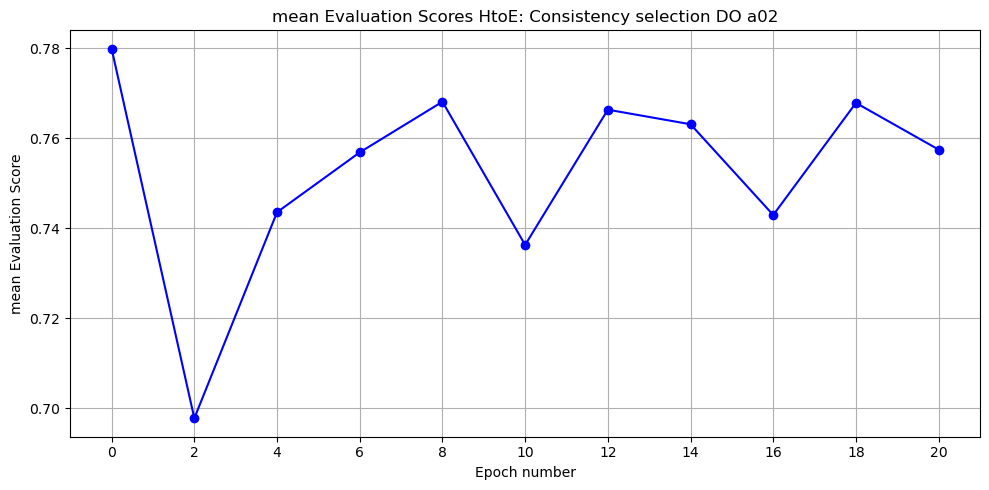

In [25]:
plot_performance_per_epoch(
    DO_mean_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Consistency selection DO a02",
    average="mean",
)

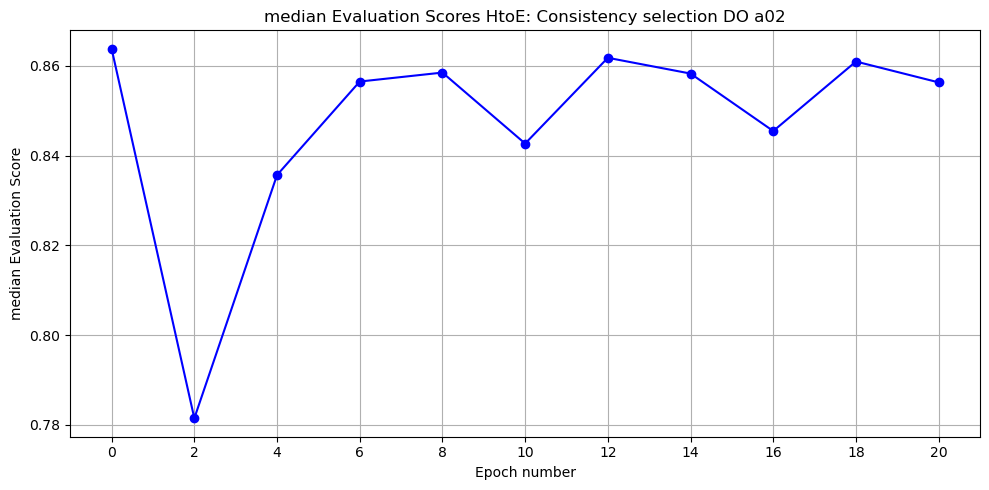

In [27]:
plot_performance_per_epoch(
    DO_median_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Consistency selection DO a02",
    average="median",
)

# MeanTeacher Finetuning: Input Gaussian consistency Pseudolabeler

In [28]:
gauss_mean_eval_scores, gauss_median_eval_scores = get_ckpt_eval_scores(
    "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/input_perturbation/predictions/HtoE_gauss_a0-005_model1",
    list(range(2, 22, 2)),
)
gauss_mean_eval_scores.insert(0, eval_direct_mean[1])
gauss_median_eval_scores.insert(0, eval_direct_median[1])

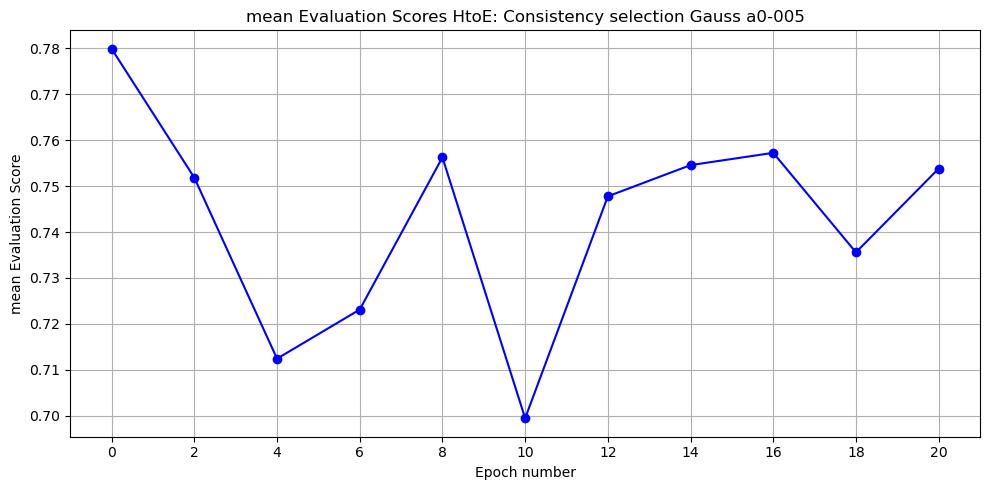

In [29]:
plot_performance_per_epoch(
    gauss_mean_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Consistency selection Gauss a0-005",
    average="mean",
)

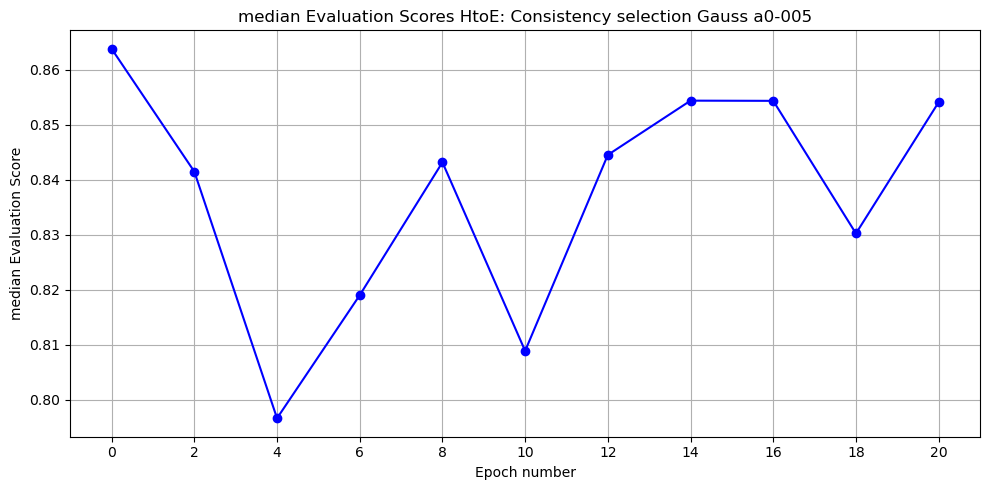

In [30]:
plot_performance_per_epoch(
    gauss_median_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Consistency selection Gauss a0-005",
    average="median",
)

# Default Self-training

In [31]:
def_mean_eval_scores, def_median_eval_scores = get_ckpt_eval_scores(
    "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/default_selftraining/predictions/HtoE_def_model1",
    list(range(2, 22, 2)),
)
def_mean_eval_scores.insert(0, eval_direct_mean[1])
def_median_eval_scores.insert(0, eval_direct_median[1])

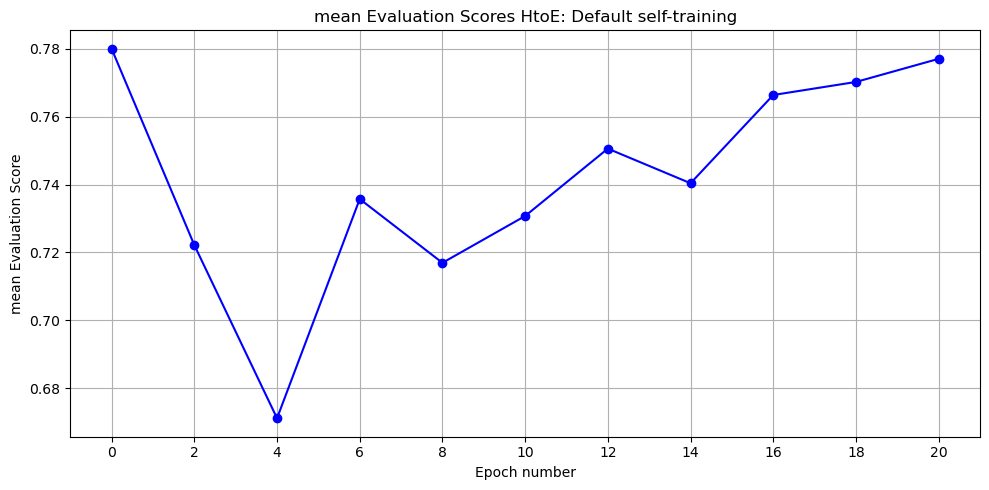

In [32]:
plot_performance_per_epoch(
    def_mean_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Default self-training",
    average="mean",
)

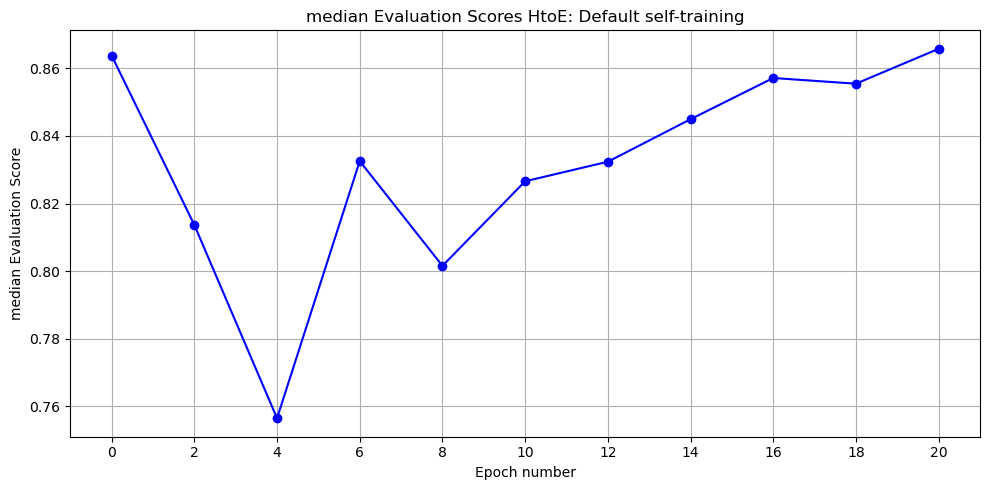

In [33]:
plot_performance_per_epoch(
    def_median_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Default self-training",
    average="median",
)

# Confidence Threshold

In [34]:
cfd_mean_eval_scores, cfd_median_eval_scores = get_ckpt_eval_scores(
    "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/confidence_threshold/predictions/HtoE_cfd_model1",
    list(range(2, 22, 2)),
)
cfd_mean_eval_scores.insert(0, eval_direct_mean[1])
cfd_median_eval_scores.insert(0, eval_direct_median[1])

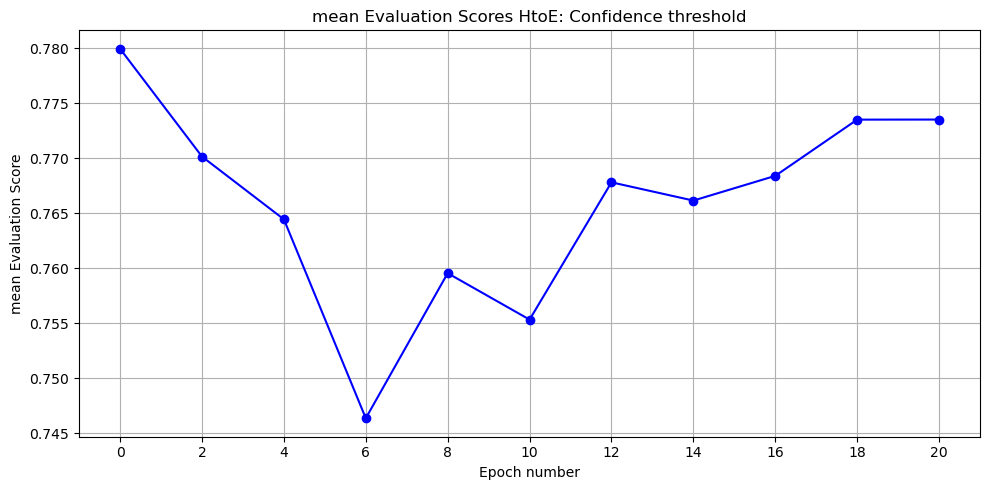

In [35]:
plot_performance_per_epoch(
    cfd_mean_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Confidence threshold",
    average="mean",
)

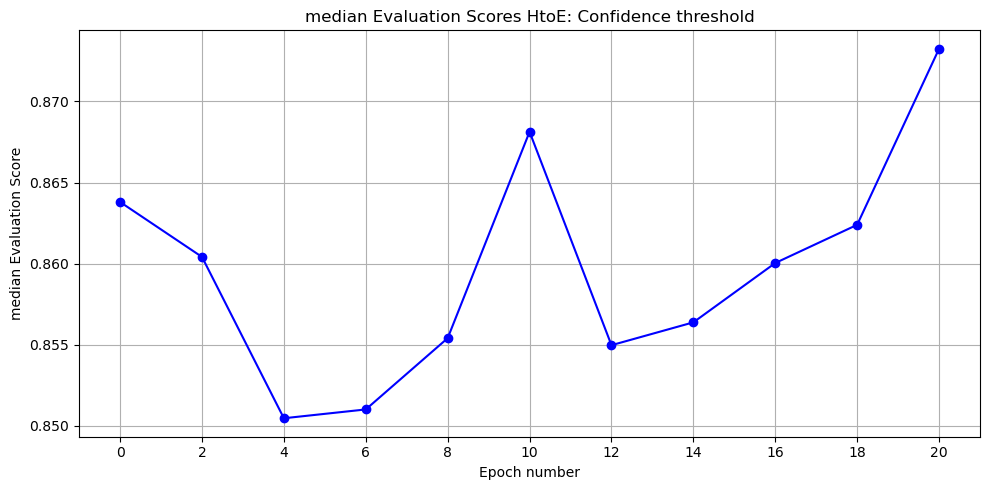

In [36]:
plot_performance_per_epoch(
    cfd_median_eval_scores,
    list(range(0, 22, 2)),
    "HtoE",
    "Confidence threshold",
    average="median",
)

# Combined

In [38]:
DO_mean_eval_scores2, DO_median_eval_scores2 = get_ckpt_eval_scores(
    "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/predictions/HtoE_DO_a02_model2",
    list(range(2, 22, 2)),
)
DO_mean_eval_scores2.insert(0, eval_direct_mean[1])
DO_median_eval_scores2.insert(0, eval_direct_median[1])

In [41]:
DO_mean_eval_scores3, DO_median_eval_scores3 = get_ckpt_eval_scores(
    "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/predictions/HtoE_DO_a02_model3",
    list(range(2, 22, 2)),
)
DO_mean_eval_scores3.insert(0, eval_direct_mean[1])
DO_median_eval_scores3.insert(0, eval_direct_median[1])

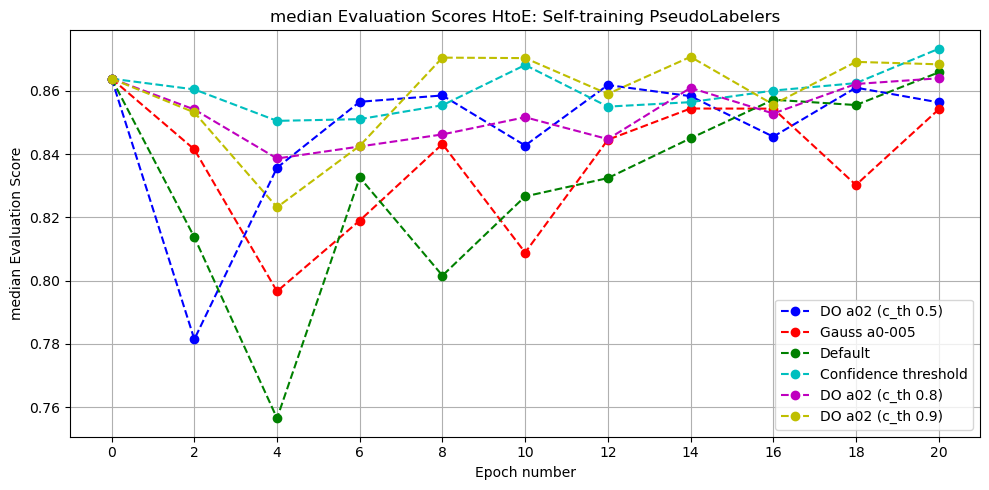

In [42]:
epochs = list(range(0, 22, 2))
average = "median"
transfer = "HtoE"
title = "Self-training PseudoLabelers"
_ = plt.figure(figsize=(10,5))
_ = plt.plot(epochs, DO_median_eval_scores, marker='o', linestyle='--', color='b', label='DO a02 (c_th 0.5)')
_ = plt.plot(epochs, gauss_median_eval_scores, marker='o', linestyle='--', color='r', label='Gauss a0-005')
_ = plt.plot(epochs, def_median_eval_scores, marker='o', linestyle='--', color='g', label='Default')
_ = plt.plot(epochs, cfd_median_eval_scores, marker='o', linestyle='--', color='c', label='Confidence threshold')
_ = plt.plot(epochs, DO_median_eval_scores2, marker='o', linestyle='--', color='m', label='DO a02 (c_th 0.8)')
_ = plt.plot(epochs, DO_median_eval_scores3, marker='o', linestyle='--', color='y', label='DO a02 (c_th 0.9)')
_ =plt.title(f'{average} Evaluation Scores {transfer}: {title}')
_ =plt.xlabel('Epoch number')
_ =plt.ylabel(f'{average} Evaluation Score')
_ = plt.xticks(epochs)
_ = plt.legend()
plt.grid()
plt.tight_layout()
#plt.savefig("mean_eval_scores_over_checkpoints.png")
plt.show()

In [2]:
from pathlib import Path
path = "/g/kreshuk/talks/segmentation_ModelSelection/experiments/Hmito/BatchNorm/Hm_model3/best_checkpoint.pytorch"
path = Path(path)
print(path.stem)

best_checkpoint


In [5]:
from pathlib import Path
from typing import List

def find_pred_paths(
    model_names: List[str], 
    approach: str = "feature_perturbation", 
    base_path: Path = Path("/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria")
) -> List[Path]:
    paths: List[Path] = []
    for model in model_names:
        transfer = model.split("_")[0]
        source = transfer.split("to")[0]
        target = transfer.split("to")[1]
        path = list(base_path.glob(f"{source}*_to_{target}*_gap/{approach}/predictions/{model}"))
        assert len(path) == 1, f"Found {len(path)} paths for {model} in {base_path}"
        paths.append(path[0])
    return paths

In [ ]:
path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_EPFL_gap/consistency/P_3/Hm_model3/norm_Normalize/none/predictions/test_none.h5"
eval_score_direct = load_h5(path, "hard_f1")
eval_direct_mean = np.mean(eval_score_direct, axis=0)
eval_direct_median = np.median(eval_score_direct, axis=0)

In [21]:
from model_ranking import get_output_dir, get_output_paths

paths = get_output_paths(
    "Hmito", "EPFL", {"none": []}, [None], "Hm_model3", "predictions", result_folder ="FP_3", base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
)
for path in paths:
    print(path)

/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_EPFL_gap/feature_perturbation_consistency/FP_3/Hm_model3/norm_Normalize/none/predictions


In [ ]:
import re
from typing import Optional

def identify_transfer(path: Path) -> Optional[str]:
    match = re.search(r'[^/]*_to_[^/]*_gap', str(path))
    return match.group(0) if match else None

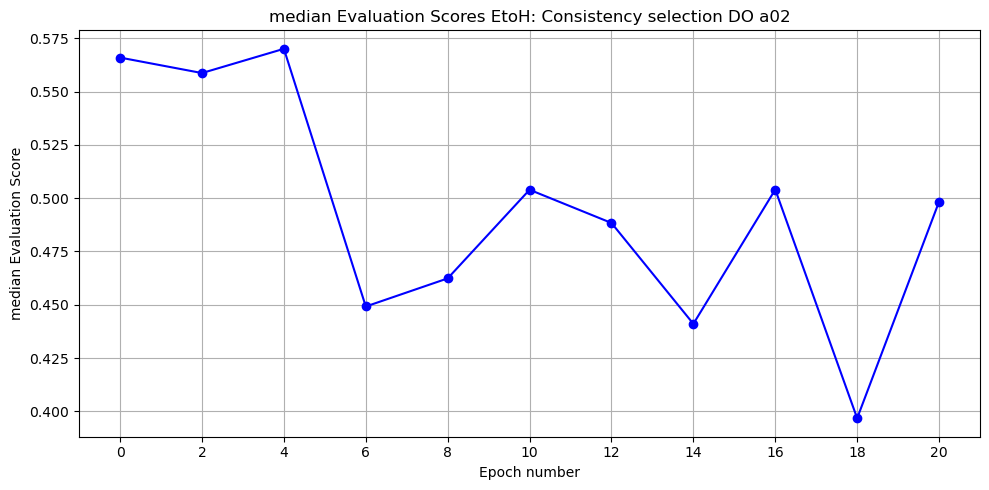

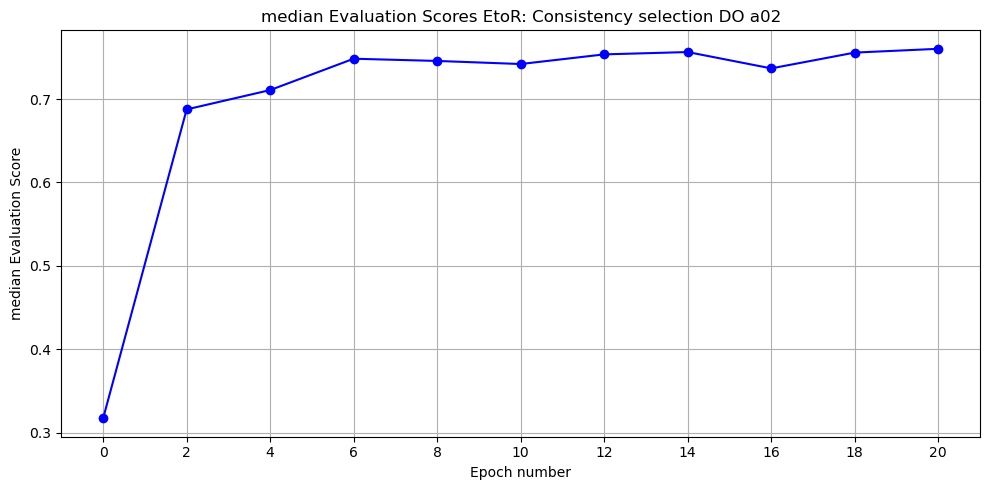

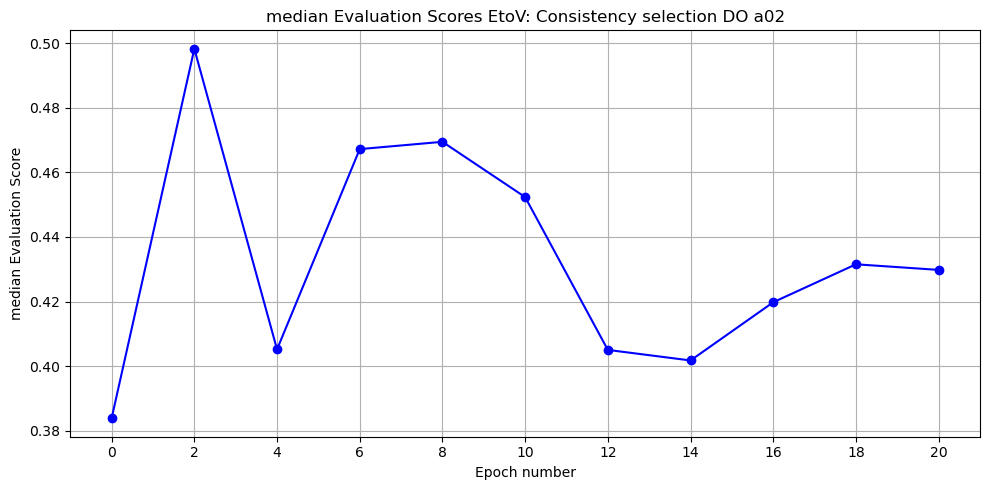

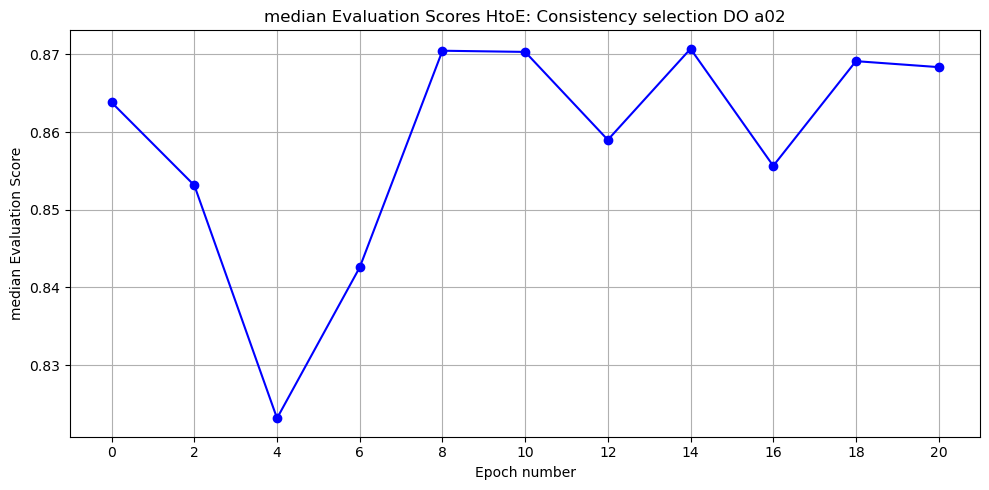

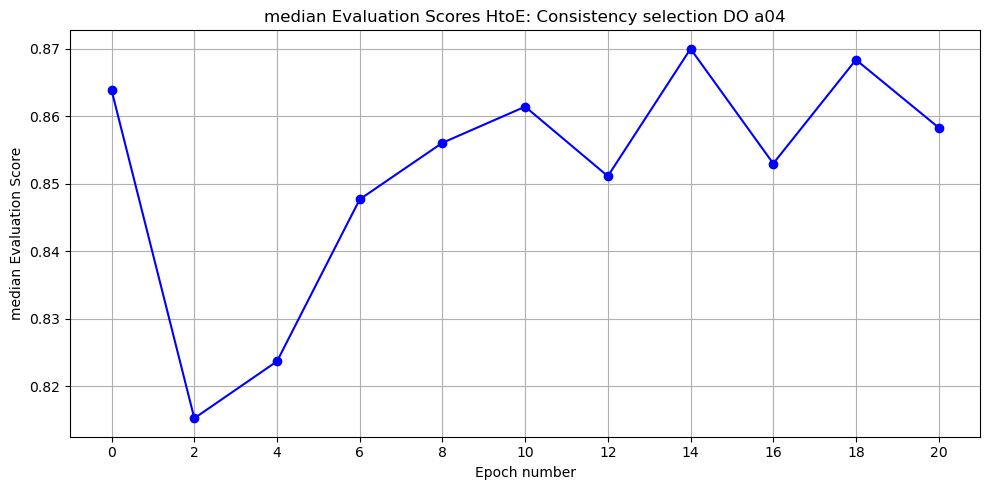

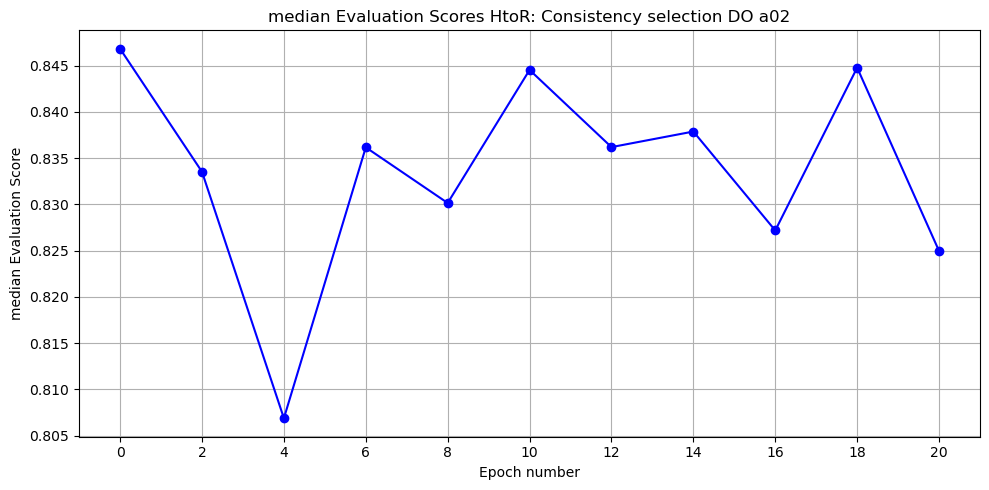

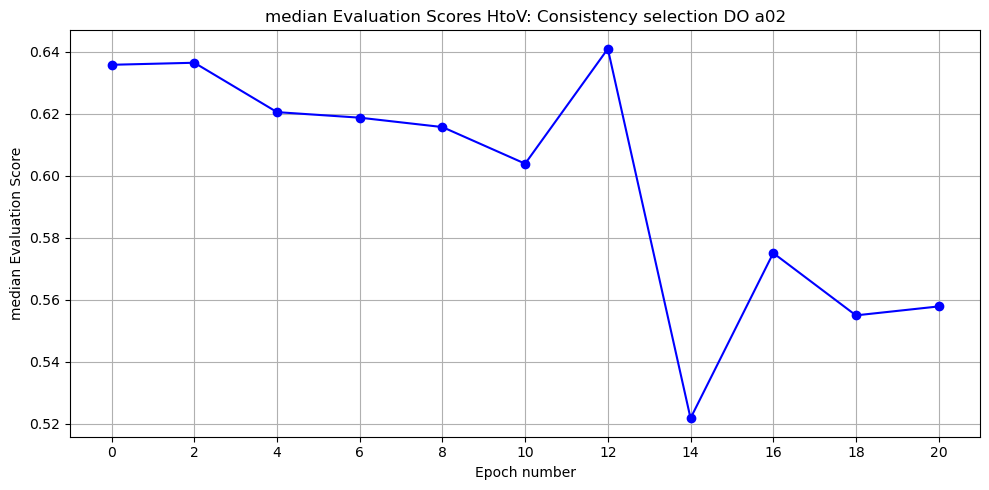

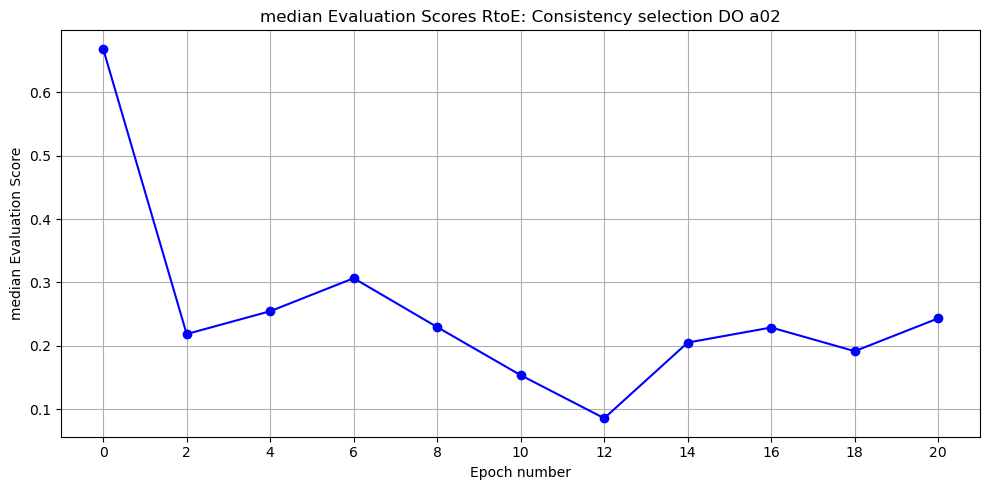

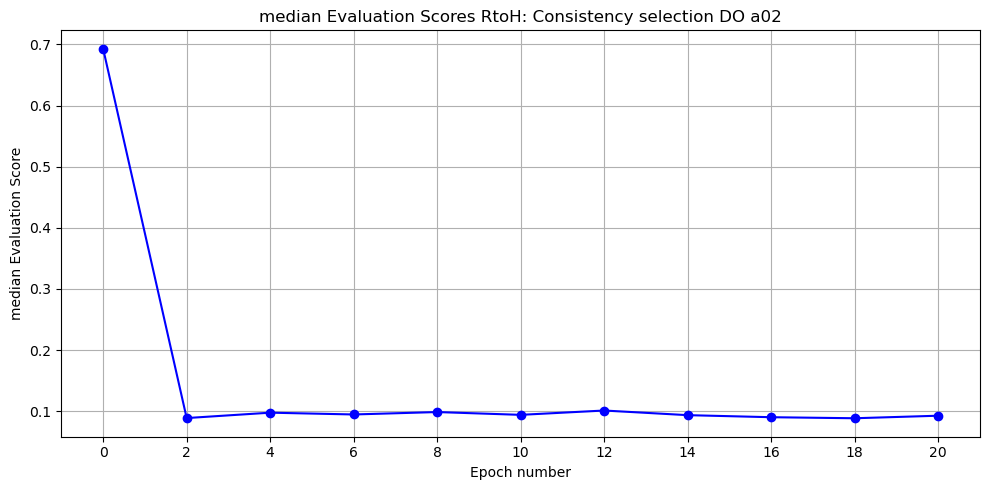

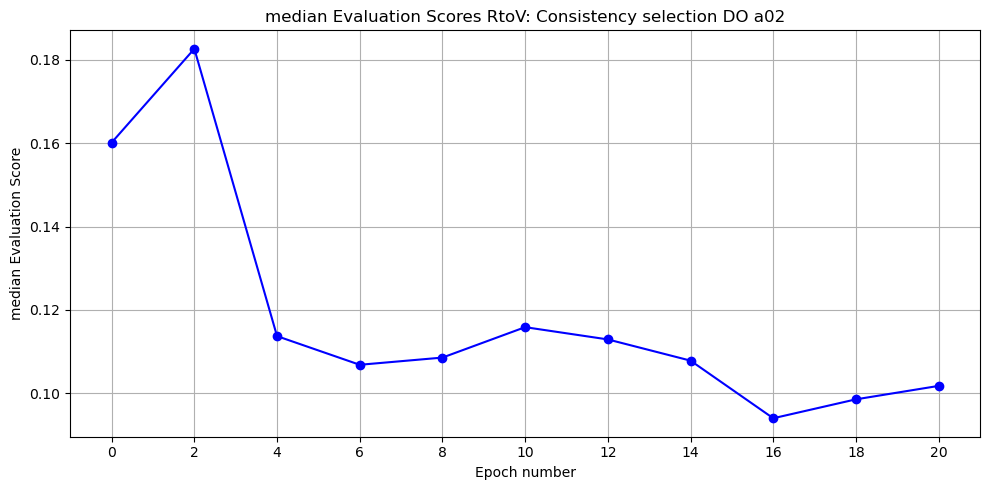

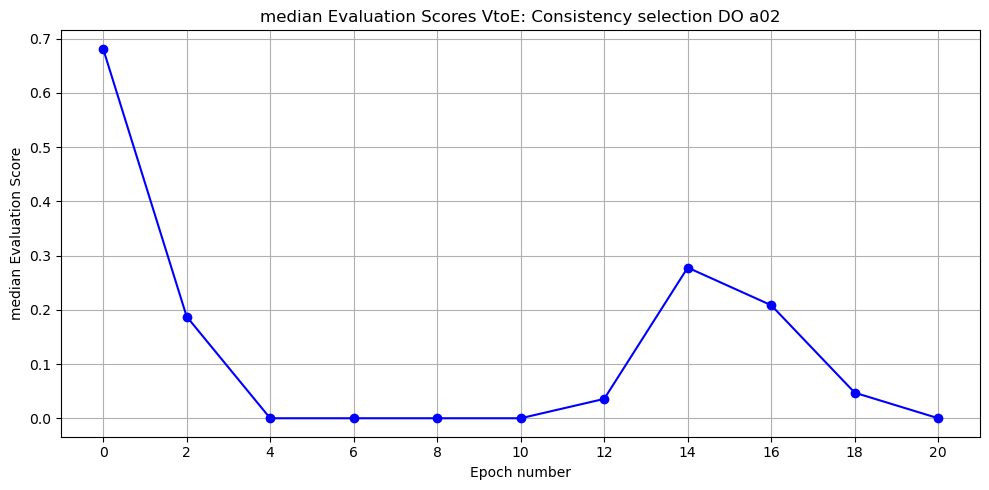

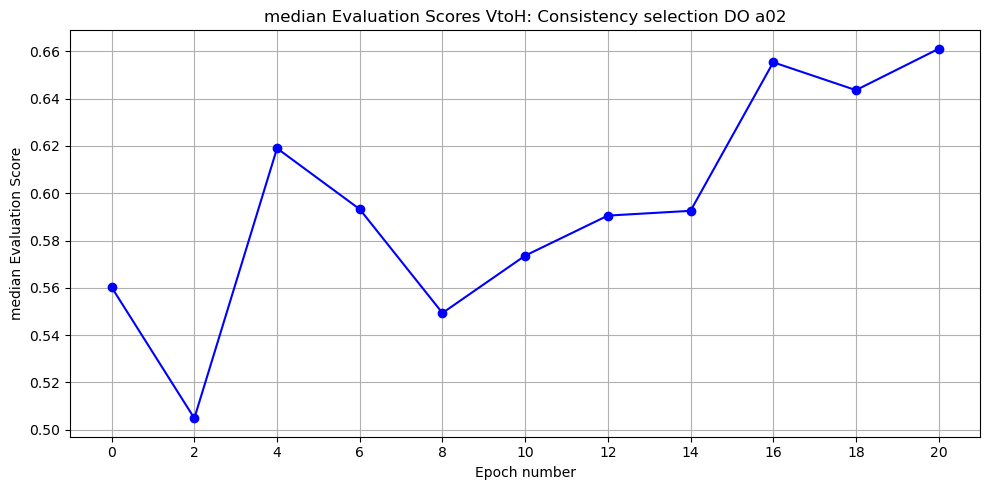

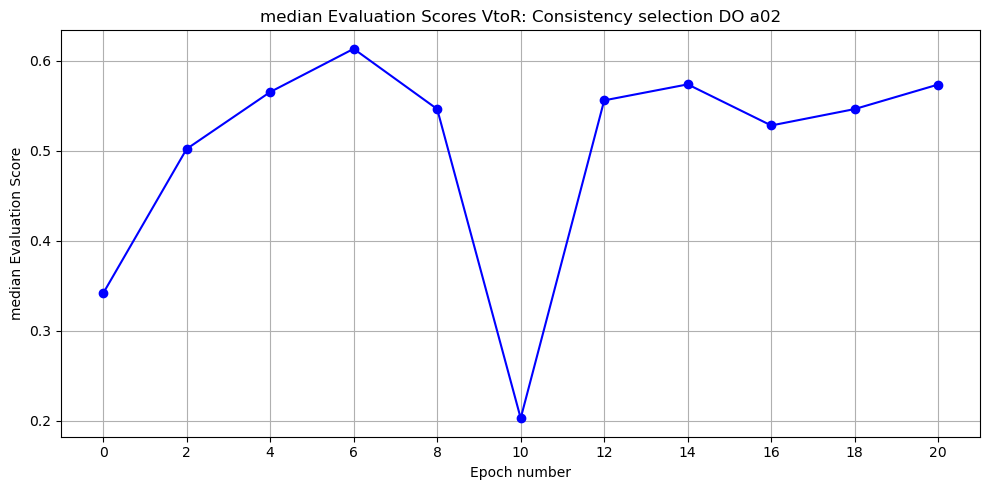

In [ ]:
from pytorch3dunet.unet3d.config import load_config_direct

models = [
    "EtoH_DO_a02_model1", 
    "EtoR_DO_a02_model1", 
    "EtoV_DO_a02_model1",
    "HtoE_DO_a02_model3",
    "HtoE_DO_a04_model1",
    "HtoR_DO_a02_model1",
    "HtoV_DO_a02_model1",
    "RtoE_DO_a02_model1",
    "RtoH_DO_a02_model1",
    "RtoV_DO_a02_model1",
    "VtoE_DO_a02_model1",
    "VtoH_DO_a02_model1",
    "VtoR_DO_a02_model1",

]

pred_paths = find_pred_paths(models)
for path in pred_paths:
    yaml_path = path.parent.parent.parent / "self_training_config.yaml"
    base_model_name = Path(load_config_direct(yaml_path)[0]["training"]["model_cfg"]["source_checkpoint"]).parent.stem
    transfer = identify_transfer(path)
    assert transfer is not None, f"Transfer section not found in path: {path}"
    target = transfer.split("_")[2]
    if target == "VNC":
        result_folder = "resized"
    else:
        result_folder = "FP_3"
    paths = get_output_paths(
        transfer.split("_")[0], 
        transfer.split("_")[2], 
        {"none": []}, 
        [None], 
        base_model_name, 
        "predictions", 
        result_folder =result_folder, 
        base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
    )
    assert len(paths) == 1, f"Expected one path for {transfer} {base_model_name}, found {len(paths)}"
    pred_path = list(Path(paths[0]).glob("*.h5"))
    eval_score_direct = load_h5(pred_path[0], "hard_f1")
    eval_direct_median = np.median(eval_score_direct, axis=0)
    mean_eval_scores, median_eval_scores = get_ckpt_eval_scores(path, list(range(2, 22, 2)))
    median_eval_scores.insert(0, eval_direct_median[1])
    plot_performance_per_epoch(
        median_eval_scores,
        list(range(0, 22, 2)),
        path.stem.split("_")[0],
        f"Consistency selection {' '.join(path.stem.split('_')[1:3])}",
        average="median",
    )

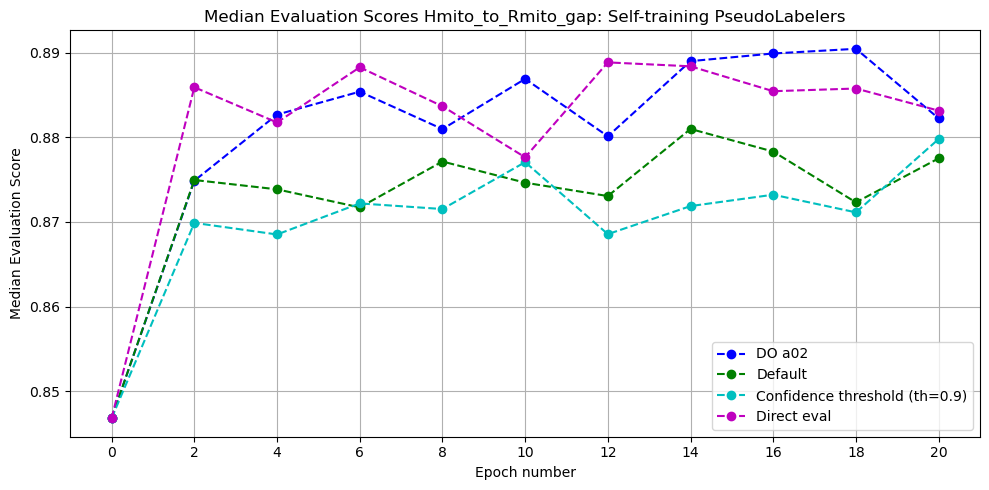

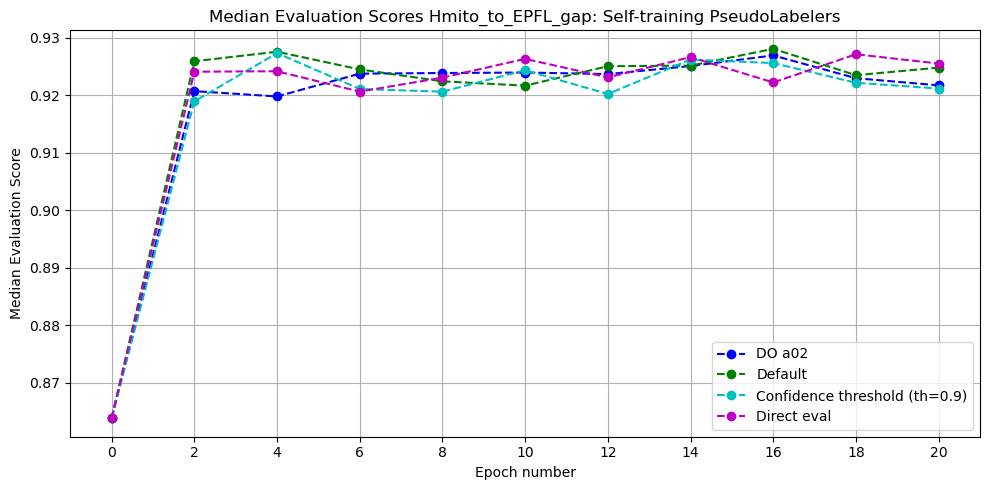

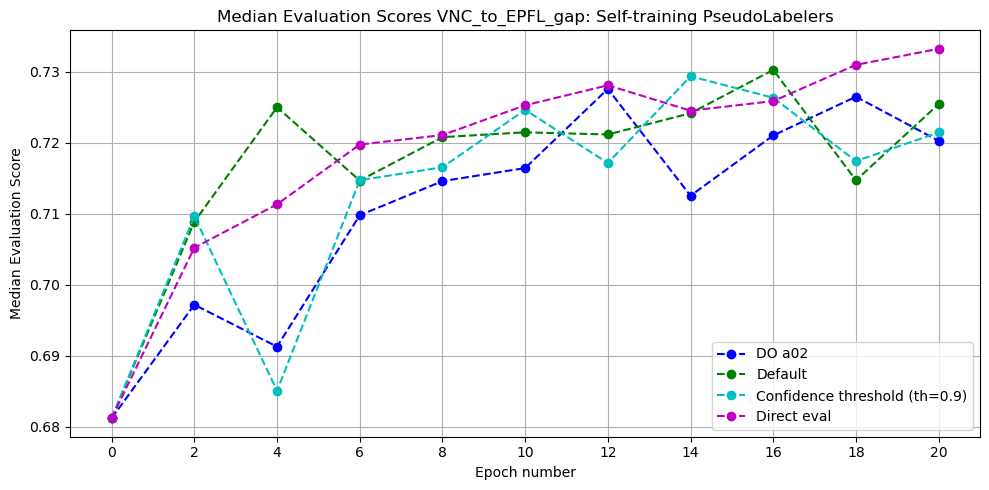

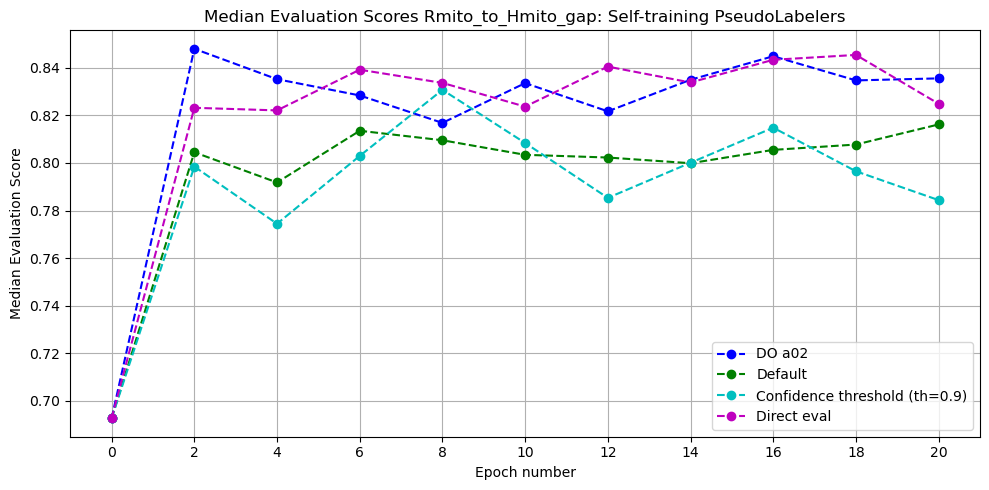

In [ ]:
from pytorch3dunet.unet3d.config import load_config_direct
from model_ranking import get_output_paths

models_DO = [
    "HtoR_DOa02_th08_new_model1",
    "HtoE_DOa02_th08_new_model1",
    "VtoE_DOa02_th07_new_model1",
    "RtoH_DOa02_th08_new_model1",
]

models_def = [
    "HtoR_def_new_model1",
    "HtoE_def_new_model1",
    "VtoE_def_new_model1",
    "RtoH_def_new_model1",
]

models_cfd = [
    "HtoR_cfd09_new_model1",
    "HtoE_cfd09_new_model1",
    "VtoE_cfd09_new_model1",
    "RtoH_cfd09_new_model1",
]

models_direct = [
    "HtoR_F108_new_model1",
    "HtoE_F108_new_model2",
    "VtoE_F106_model1",
    "RtoH_F107_new_model1",
]

models_SF = []

for i, model_DO_name in enumerate(models_DO):
    model_def_name = models_def[i]
    model_cfd_name = models_cfd[i]
    model_F1_name = models_direct[i]
    assert (
        model_DO_name.split("_")[0] == model_def_name.split("_")[0] == model_cfd_name.split("_")[0] == model_F1_name.split("_")[0]
    ), f"Model transfers do not match: {model_DO_name}, {model_def_name}, {model_cfd_name}"

    pred_DO_path = find_selftraining_pred_paths([model_DO_name], approach="feature_perturbation")[0]
    pred_def_path = find_selftraining_pred_paths([model_def_name], approach="default_selftraining")[0]
    pred_cfd_path = find_selftraining_pred_paths([model_cfd_name], approach="confidence_threshold")[0]
    pred_F1_path = find_selftraining_pred_paths([model_F1_name], approach="direct_eval")[0]

    yaml_path = pred_DO_path.parent.parent.parent / "self_training_config.yaml"
    base_model_name = Path(load_config_direct(yaml_path)[0]["training"]["model_cfg"]["source_checkpoint"]).parent.stem
    transfer = identify_transfer(pred_DO_path)
    assert transfer is not None, f"Transfer section not found in path: {pred_DO_path}"
    target = transfer.split("_")[2]
    if target == "VNC":
        result_folder = "resized"
    else:
        result_folder = "FP_3"
    paths = get_output_paths(
        transfer.split("_")[0], 
        transfer.split("_")[2], 
        {"none": []}, 
        [None], 
        base_model_name, 
        "predictions", 
        result_folder =result_folder, 
        base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
    )
    assert len(paths) == 1, f"Expected one path for {transfer} {base_model_name}, found {len(paths)}"
    pred_path = list(Path(paths[0]).glob("*.h5"))
    eval_score_direct = load_h5(pred_path[0], "hard_f1")
    eval_direct_median = np.median(eval_score_direct, axis=0)

    mean_DO_eval_scores, median_DO_eval_scores = get_ckpt_eval_scores(pred_DO_path, list(range(2, 22, 2)))
    mean_def_eval_scores, median_def_eval_scores = get_ckpt_eval_scores(pred_def_path, list(range(2, 22, 2)))
    mean_cfd_eval_scores, median_cfd_eval_scores = get_ckpt_eval_scores(pred_cfd_path, list(range(2, 22, 2)))
    mean_F1_eval_scores, median_F1_eval_scores = get_ckpt_eval_scores(pred_F1_path, list(range(2, 22, 2)))
    median_DO_eval_scores.insert(0, eval_direct_median[1])
    median_def_eval_scores.insert(0, eval_direct_median[1])
    median_cfd_eval_scores.insert(0, eval_direct_median[1])
    median_F1_eval_scores.insert(0, eval_direct_median[1])
    epochs = list(range(0, 22, 2))
    _ = plt.figure(figsize=(10,5))
    _ = plt.plot(epochs, median_DO_eval_scores, marker='o', linestyle='--', color='b', label='DO a02')
    _ = plt.plot(epochs, median_def_eval_scores, marker='o', linestyle='--', color='g', label='Default')
    _ = plt.plot(epochs, median_cfd_eval_scores, marker='o', linestyle='--', color='c', label='Confidence threshold (th=0.9)')
    _ = plt.plot(epochs, median_F1_eval_scores, marker='o', linestyle='--', color='m', label='Direct eval')
    _ =plt.title(f'Median Evaluation Scores {transfer}: Self-training PseudoLabelers')
    _ =plt.xlabel('Epoch number')
    _ =plt.ylabel(f'Median Evaluation Score')
    _ = plt.xticks(epochs)
    _ = plt.legend()
    plt.grid()
    plt.tight_layout()
    #plt.savefig("mean_eval_scores_over_checkpoints.png")
    plt.show()

Transfer: HtoE


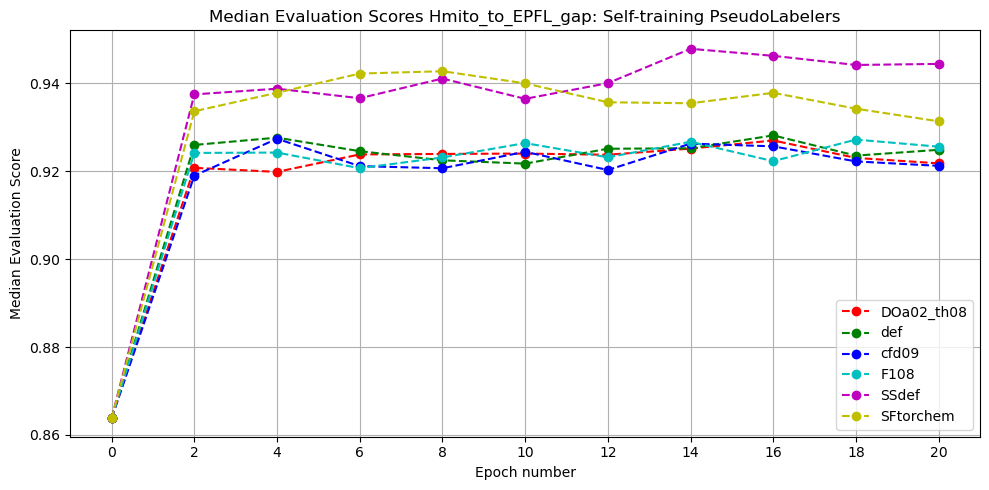

Transfer: VtoE


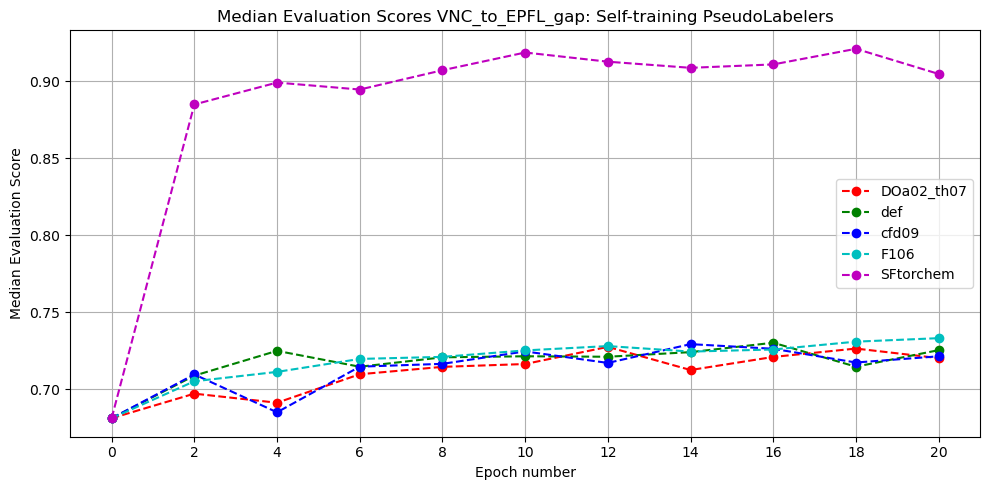

Transfer: HtoR


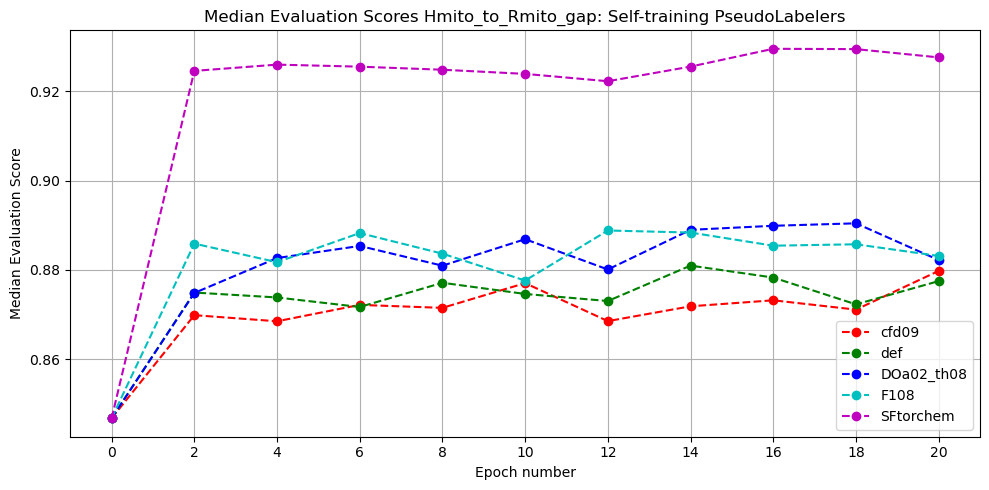

Transfer: RtoH


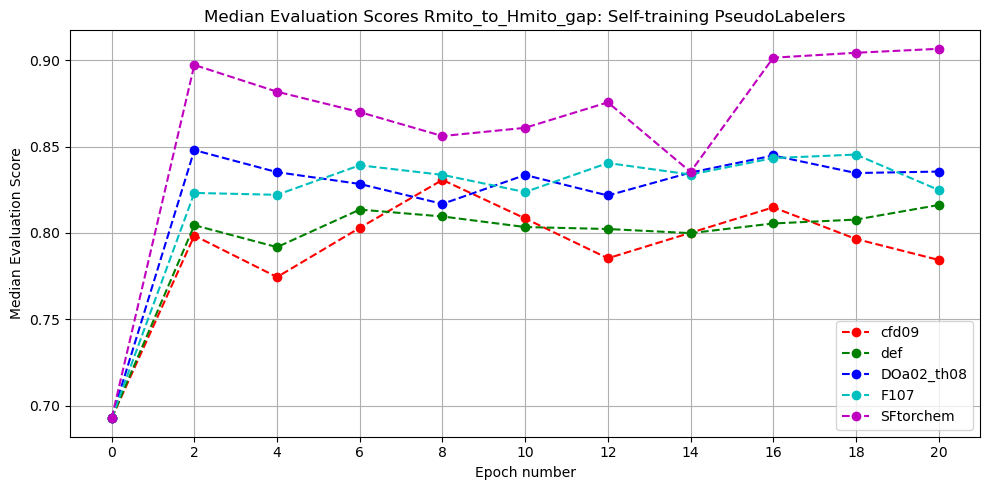

In [4]:
from pytorch3dunet.unet3d.config import load_config_direct
from model_ranking import get_output_paths
from typing import Dict, List

approach_mapping = {
    "DO": "feature_perturbation",
    "def": "default_selftraining",
    "cfd": "confidence_threshold",
    "F1": "direct_eval",
    "torchem": "supervised_torchem",
    "_SF_": "supervised",
    "ST": "supervised_training",
}

models: Dict[str, List[str]] = {
    "HtoE": [
        "HtoE_DOa02_th08_new_model1",
        "HtoE_def_new_model1",
        "HtoE_cfd09_new_model1",
        "HtoE_F108_new_model2", 
        "HtoE_SSdef_new_model1", 
        "HtoE_SFtorchem_model5",
    ],
    "VtoE": [
        "VtoE_DOa02_th07_new_model1",
        "VtoE_def_new_model1",
        "VtoE_cfd09_new_model1",
        "VtoE_F106_model1",
        "VtoE_SFtorchem_new_model1",
    ],
    "HtoR": [
        "HtoR_cfd09_new_model1",
        "HtoR_def_new_model1",
        "HtoR_DOa02_th08_new_model1",
        "HtoR_F108_new_model1",
        "HtoR_SFtorchem_new_model1",
    ],
    "RtoH": [
        "RtoH_cfd09_new_model1",
        "RtoH_def_new_model1",
        "RtoH_DOa02_th08_new_model1",
        "RtoH_F107_new_model1",
        "RtoH_SFtorchem_new_model1",
    ],
}


models_DO= [
    #"HtoE_DOa02_th08_new_model1"
    "VtoE_DOa02_th07_new_model1",
]
models_def = [
    #"HtoE_def_new_model1",
    "VtoE_def_new_model1",
]
models_cfd = [
    #"HtoE_cfd09_new_model1",
    "VtoE_cfd09_new_model1",
]
models_direct = [
    #"HtoE_F108_new_model2"
    "VtoE_F106_model1",
]
models_SS = [
    #"HtoE_SSdef_new_model1",
]
models_SF = [
    #"HtoE_SFtorchem_model5",
    "VtoE_SFtorchem_new_model1",
]
models_ST = [
    #"E_ST_model2",
]

#models = models_DO + models_def + models_cfd + models_direct + models_SS + models_SF
colours = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'pink', 'gray']
for transfer, model_list in models.items():
    print(f"Transfer: {transfer}")
    _ = plt.figure(figsize=(10,5))
    for i, model_name in enumerate(model_list):

        if "SS" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/SemiSupervised-Finetuning/Mitochondria")
        elif "SF" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Supervised-Finetuning/Mitochondria")
        elif "ST" in model_name:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Supervised-training/Mitochondria")
        else:
            base_path = Path("/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria")
        approach = None
        label = None
        for key in approach_mapping:
            if key in model_name:
                approach = approach_mapping[key]
                if key == "DO":
                    label = "_".join(model_name.split("_")[1:3])
                else:
                    label = model_name.split("_")[1]
                break

        assert approach is not None, f"Approach not found for model: {model_name}"
        assert label is not None, f"Label not found for model: {model_name}"

        pred_path = find_selftraining_pred_paths([model_name], approach=approach, base_path=base_path)[0]

        yaml_path = pred_path.parent.parent.parent / "self_training_config.yaml"
        base_model_name = Path(load_config_direct(yaml_path)[0]["training"]["model_cfg"]["source_checkpoint"]).parent.stem
        transfer = identify_transfer(pred_path)
        assert transfer is not None, f"Transfer section not found in path: {pred_path}"
        target = transfer.split("_")[2]
        if target == "VNC":
            result_folder = "resized"
        else:
            result_folder = "FP_3"
        paths = get_output_paths(
            transfer.split("_")[0], 
            transfer.split("_")[2], 
            {"none": []}, 
            [None], 
            base_model_name, 
            "predictions", 
            result_folder =result_folder, 
            base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
        )
        assert len(paths) == 1, f"Expected one path for {transfer} {base_model_name}, found {len(paths)}"
        direct_pred_path = list(Path(paths[0]).glob("*.h5"))
        eval_score_direct = load_h5(direct_pred_path[0], "hard_f1")
        eval_direct_median = np.median(eval_score_direct, axis=0)

        if "_SF_" in model_name:
            epoch_ids = list(range(1, 21, 2))
            #epoch_ids = list(range(1, 5, 2))
        else:
            epoch_ids = list(range(2, 22, 2))
            #epoch_ids = list(range(1, 3, 1))


        mean_eval_scores, median_eval_scores = get_ckpt_eval_scores(pred_path, epoch_ids)
        median_eval_scores.insert(0, eval_direct_median[1])
        epochs = list(range(0, 22, 2))
        #epochs = epoch_ids.copy()
        #epochs.insert(0,0)  # Include the direct evaluation at epoch 0
        
        _ = plt.plot(epochs, median_eval_scores, marker='o', linestyle='--', color=colours[i], label=label)

    _ =plt.title(f'Median Evaluation Scores {transfer}: Self-training PseudoLabelers')
    _ =plt.xlabel('Epoch number')
    _ =plt.ylabel(f'Median Evaluation Score')
    _ = plt.xticks(epochs)
    _ = plt.legend()
    plt.grid()
    plt.tight_layout()
        #plt.savefig("mean_eval_scores_over_checkpoints.png")
    plt.show()


In [12]:
a = np.load("/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/pseudo_labeler/HtoE_DO_a02_model3/09_consis_threshold_EI/patch_selection_epoch-2.npz")
consis_scores = a["consis_scores"]
accepted_ids = a["accepted_ids"]

In [14]:
print(accepted_ids)

[ 44  70  71  72  77  78  94 100 101 106 107 112 113 118 119 124 130 136
 142 148 162 168 174 178 180 186 190 192 196 220 222 226 228 232 234 238
 244 252 254 262 264 268 274 280 286 292 298 304 310 316 328 342 352 358
 370 376 380 386 392 393 394 398 404 410 422 424 428 430 434 472 487 488
 490 493 494 496 499 502 506 508 512 514 516 518 520 526 532 538 541 544
 547 550 553 554 555 556 559 561 562 565 566 567 568 571 572 574 580 582
 586 592 596 598 601 604 606 607 608 610 613 614 616 619 620 622 624 625
 626 628 631 632 634 637 640 646 650 652 655 656 658 661 662 664 667 668
 670 673 674 679 680 685 686 690 691 692 693 696 697 698 703 708 709 710
 715 721 727 751 757 763 767 769 773 774 775 777 779 781 783 785 787 789
 791 793 799 805 809 811 812 815 817 818 823 824 825 827 829 830 835 836
 851 853 854 855 859 865 871 873 877 882 883 889 895 901 907 913 914 919
 924 925 949 973 981 985]


In [16]:
print(consis_scores[64:86])

[0.86492229 0.89907694 0.86905336 0.74429083 0.83568883        nan
 0.91226786 0.90092874 0.90227008 0.78154337 0.87175035        nan
 0.89234018 0.90360004 0.91043466 0.7773785  0.80289823        nan
 0.85768759 0.87983978 0.87093848 0.6832518 ]


In [1]:
1920/32

60.0

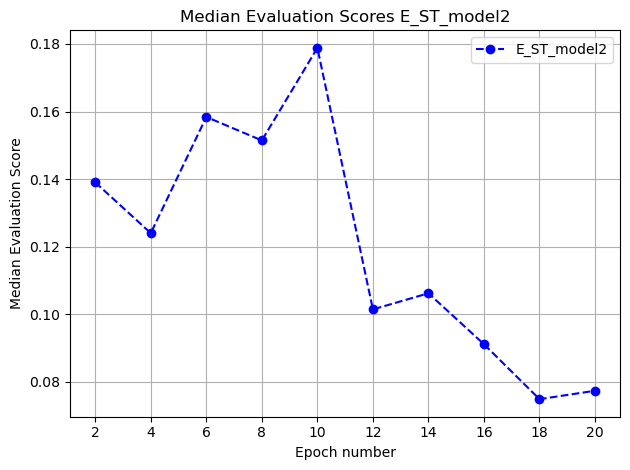

In [10]:
pred_path = "/g/kreshuk/talks/model_ranking_results/Supervised-training/Mitochondria/Hmito_to_EPFL_gap/supervised_training/predictions/E_ST_model2"
mean_eval_scores, median_eval_scores = get_ckpt_eval_scores(pred_path, list(range(2, 22, 2)))
_ = plt.plot(list(range(2, 22, 2)), median_eval_scores, marker='o', linestyle='--', color='b', label='E_ST_model2')
_ = plt.title(f'Median Evaluation Scores E_ST_model2')
_ = plt.xlabel('Epoch number')
_ = plt.ylabel(f'Median Evaluation Score')
_ = plt.xticks(list(range(2, 22, 2)))
_ = plt.legend()
plt.grid()
plt.tight_layout()

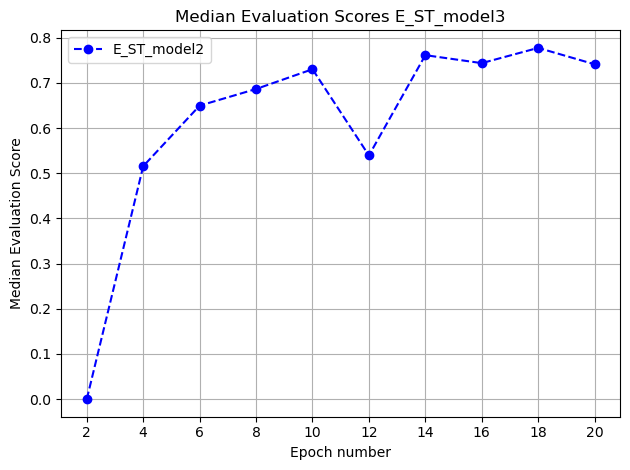

In [4]:
pred_path = "/g/kreshuk/talks/model_ranking_results/Supervised-training/Mitochondria/Hmito_to_EPFL_gap/supervised_training/predictions/E_ST_model3"
mean_eval_scores, median_eval_scores = get_ckpt_eval_scores(pred_path, list(range(2, 22, 2)))
_ = plt.plot(list(range(2, 22, 2)), median_eval_scores, marker='o', linestyle='--', color='b', label='E_ST_model2')
_ = plt.title(f'Median Evaluation Scores E_ST_model3')
_ = plt.xlabel('Epoch number')
_ = plt.ylabel(f'Median Evaluation Score')
_ = plt.xticks(list(range(2, 22, 2)))
_ = plt.legend()
plt.grid()
plt.tight_layout()

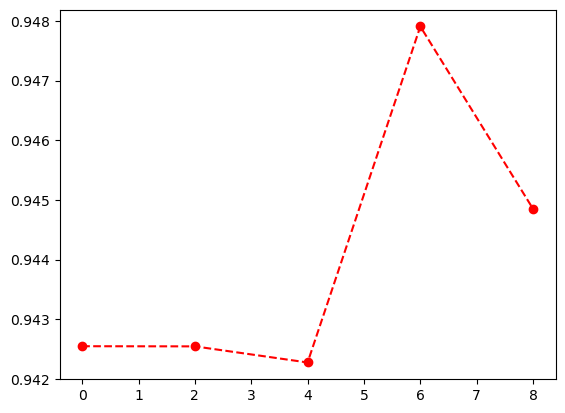

In [10]:
path = find_selftraining_pred_paths(["HtoE_SF_model1"], approach="supervised", base_path=Path("/g/kreshuk/talks/model_ranking_results/Supervised-Finetuning/Mitochondria"))[0]
mean_eval_scores, median_eval_scores = get_ckpt_eval_scores(path, list(range(0, 10, 2)))
epochs = list(range(0, 10, 2))
_ = plt.plot(epochs, median_eval_scores, marker='o', linestyle='--', color='r', label="supervised")

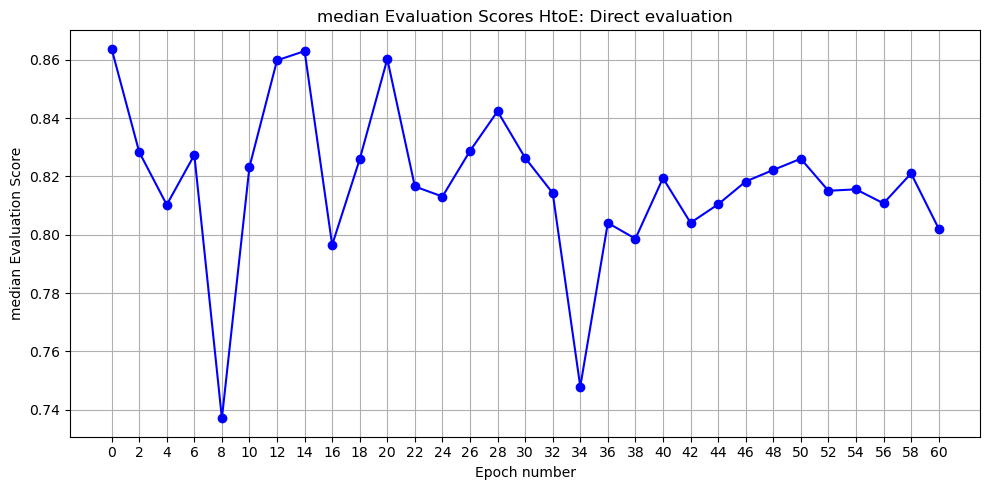

In [ ]:
models = [
    "HtoE_F1_model1",
    "HtoE_F1_model1_extra1"
]

pred_paths = find_selftraining_pred_paths(models, approach="direct_eval")
eval_scores = []

_, median_eval_scores_e2_20 = get_ckpt_eval_scores(pred_paths[0], list(range(2, 22, 2)))
_, median_eval_scores_e22_60 = get_ckpt_eval_scores(pred_paths[1], list(range(2, 42, 2)))
median_eval_scores = median_eval_scores_e2_20 + median_eval_scores_e22_60

yaml_path = pred_paths[0].parent.parent.parent / "self_training_config.yaml"
base_model_name = Path(load_config_direct(yaml_path)[0]["training"]["model_cfg"]["source_checkpoint"]).parent.stem
transfer = identify_transfer(pred_paths[0])
assert transfer is not None, f"Transfer section not found in path: {pred_paths[0]}"
target = transfer.split("_")[2]
if target == "VNC":
    result_folder = "resized"
else:
    result_folder = "FP_3"
paths = get_output_paths(
    transfer.split("_")[0], 
    transfer.split("_")[2], 
    {"none": []}, 
    [None], 
    base_model_name, 
    "predictions", 
    result_folder =result_folder, 
    base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
)
assert len(paths) == 1, f"Expected one path for {transfer} {base_model_name}, found {len(paths)}"
direct_pred_path = list(Path(paths[0]).glob("*.h5"))
eval_score_direct = load_h5(direct_pred_path[0], "hard_f1")
eval_direct_median = np.median(eval_score_direct, axis=0)

median_eval_scores.insert(0, eval_direct_median[1])

plot_performance_per_epoch(
    median_eval_scores,
    list(range(0, 62, 2)),
    "HtoE",
    "Direct evaluation",
    average="median",
    figsize=(10, 5),
)

In [4]:
60*32

1920

In [18]:
eval_median

[PosixPath('/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_EPFL_gap/feature_perturbation_consistency/FP_3/Hm_model3/norm_Normalize/none/predictions/test_none.h5')]